In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
# 0. load the 60 BGs for O'Hare 
gdf = gpd.read_file("OHare-CA76/ohare_60bg_v2.geojson").to_crs(4326)
geo_col = "GEOID" if "GEOID" in gdf.columns else "GEOIDBG"

gdf = gdf.drop_duplicates(subset=[geo_col]).reset_index(drop=True)
print("BG loaded:", len(gdf))

BG loaded: 60


In [ ]:
# 1. select features (same as Roseland)
features = [
    "B01003_001E",   # total population
    "B19013_001E",   # median household income
    "B01002_001E",   # median age
    "unemp_rate",
    "owner_share",
    "vacancy_rate",
]

X = gdf[features].astype(float).copy()
# fill missing values
X = X.fillna(X.median(numeric_only=True))

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled matrix shape:", X_scaled.shape)   # should be (60, 6)


Scaled matrix shape: (60, 6)


In [ ]:
# 2. build similarity graph (cosine) for O'Hare 60 BGs
sim_matrix = cosine_similarity(X_scaled)
G = nx.Graph()

# add nodes with attributes
for _, row in gdf.iterrows():
    G.add_node(
        row[geo_col],
        **{f: row[f] for f in features},
        area_num=int(row["area_num"])
    )

# add edges above a similarity threshold
threshold = 0.75   # adjust if graph is too dense / too sparse
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i, j] > threshold:
            u = gdf.iloc[i][geo_col]
            v = gdf.iloc[j][geo_col]
            G.add_edge(u, v, weight=sim_matrix[i, j])

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph built: 60 nodes, 137 edges


In [ ]:
# 3. basic network metrics (for the write-up)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_clustering = nx.average_clustering(G)
components = nx.number_connected_components(G)

print(f"Nodes: {num_nodes}, Edges: {num_edges}")
print(f"Density: {density:.3f}, Avg clustering: {avg_clustering:.3f}, Components: {components}")

Nodes: 60, Edges: 137
Density: 0.077, Avg clustering: 0.550, Components: 5


In [ ]:
# 4. community detection (greedy modularity) on the similarity graph
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G, weight="weight")
print(f"Detected {len(communities)} communities")

# assign community id back to graph nodes
for i, c in enumerate(communities):
    for node in c:
        G.nodes[node]["community"] = i


Detected 8 communities


In [ ]:
# 5. bring community labels back to the GeoDataFrame
comm_attr = nx.get_node_attributes(G, "community")
gdf["community"] = gdf[geo_col].map(comm_attr)

# quick summary table (average features by community)
summary = gdf.groupby("community")[features].mean().round(1)
print(summary)


           B01003_001E  B19013_001E  B01002_001E  unemp_rate  owner_share  \
community                                                                   
0               1184.5      96595.2         44.2         0.1          0.9   
1               2375.5      88551.2         42.3         0.0          0.7   
2               1432.4      67026.3         39.2         0.0          0.3   
3               1128.6     130864.8         43.3         0.0          0.9   
4               1363.0      76241.6         43.5         0.0          0.6   
5                749.3 -666666666.0         48.2         0.0          0.9   
6                  0.0 -666666666.0 -666666666.0         NaN          NaN   
7               1232.0      88667.0         37.6         0.0          0.6   

           vacancy_rate  
community                
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.1  
5                   0.0  
6                   N

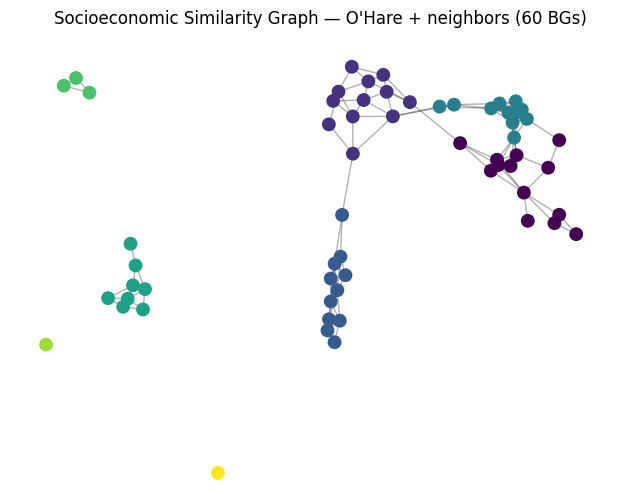

In [ ]:
# 6. plot the network 
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42, weight="weight")
colors = [G.nodes[n]["community"] for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=colors, cmap="viridis", node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Socioeconomic Similarity Graph — O'Hare + neighbors (60 BGs)")
plt.axis("off")
plt.show()

In [ ]:
# 7. connected components: “core” of O'Hare
components_list = list(nx.connected_components(G))
print(f"Connected components: {len(components_list)}")

largest = max(components_list, key=len)
print(f"Largest component size: {len(largest)}")


Connected components: 5
Largest component size: 47


In [10]:
components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")

# Assign component ID to each node
component_dict = {}
for i, comp in enumerate(components):
    for geoid in comp:
        component_dict[geoid] = i

gdf['component'] = gdf['GEOID'].map(component_dict)
print(gdf['component'].value_counts().head())

Number of connected components: 5
component
1    47
2     8
0     3
3     1
4     1
Name: count, dtype: int64


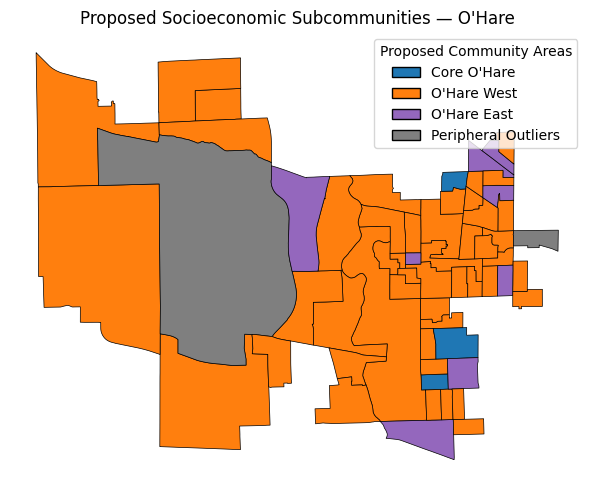

In [ ]:
import numpy as np
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# 1) Normalize labels: anything not Core/West/East -> Peripheral Outliers
keep = {"Core O'Hare", "O'Hare West", "O'Hare East"}
gdf["cluster_name"] = np.where(
    gdf["cluster_name"].isin(keep),
    gdf["cluster_name"],
    "Peripheral Outliers"
)

# 2) Fixed colors for the 4 categories
palette = {
    "Core O'Hare": "#1f77b4",          # blue
    "O'Hare West": "#ff7f0e",          # orange
    "O'Hare East": "#9467bd",          # purple
    "Peripheral Outliers": "#7f7f7f",  # gray
}
gdf["color"] = gdf["cluster_name"].map(palette)

# 3) Plot + legend
fig, ax = plt.subplots(figsize=(7, 5))
gdf.plot(ax=ax, color=gdf["color"], edgecolor="black", linewidth=0.5)
ax.set_title("Proposed Socioeconomic Subcommunities — O'Hare")
ax.axis("off")

legend_order = ["Core O'Hare", "O'Hare West", "O'Hare East", "Peripheral Outliers"]
handles = [Patch(facecolor=palette[lbl], edgecolor="black", label=lbl) for lbl in legend_order]
ax.legend(handles=handles, title="Proposed Community Areas", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


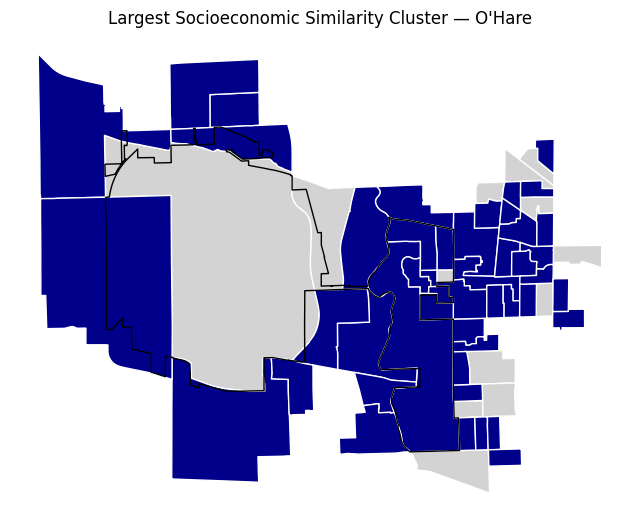

In [63]:
# 1) largest connected component from the similarity graph
largest = max(components, key=len)

# 2) mark in the GeoDataFrame which BGs belong to that largest component
geo_col = "GEOID" if "GEOID" in gdf.columns else "GEOIDBG"
gdf["in_largest"] = gdf[geo_col].isin(largest)

# 3) plot
fig, ax = plt.subplots(figsize=(8, 8))
# all 60 BG in light grey
gdf.plot(ax=ax, color="lightgrey", edgecolor="white")
# only the ones in the largest component in dark blue
gdf[gdf["in_largest"]].plot(ax=ax, color="darkblue", edgecolor="white")
# outline O'Hare
ohare.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_title("Largest Socioeconomic Similarity Cluster — O'Hare")
ax.axis("off")
plt.show()